# **Group By**

In [1]:
import numpy as np
import pandas as pd

# Load Palmer penguins data
URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'
penguins = pd.read_csv(URL)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


# Summary Statistics
Use for columns in pandas.DataFrame:

sum(): sum values in each column

count(): count non-NA values in each column

size(): count the number of values in a column (including NA values)

min() and max(): get the minimum and maximum value in each column

mean() and median(): get the mean and median value in each column

std() and var(): get the standard deviation and variance in each column

In [2]:
# Get the number of non-NA values in each column 
penguins.count()

species              344
island               344
bill_length_mm       342
bill_depth_mm        342
flipper_length_mm    342
body_mass_g          342
sex                  333
year                 344
dtype: int64

In [3]:
# Get minimum value in each column with numerical values (floats)
penguins.select_dtypes('number').min()

bill_length_mm         32.1
bill_depth_mm          13.1
flipper_length_mm     172.0
body_mass_g          2700.0
year                 2007.0
dtype: float64

# Grouping
We start with our data and notice there are multiple species in the species column.

We split our original table to group all observations from the same species together.

We calculate the average flipper length for each of the groups we formed.

Then we combine the values for average flipper length per species into a single table.

This is known as the Split-Apply-Combine strategy. This strategy follows the three steps we explained above:

Split: Split the data into logical groups (e.g. species, sex, island, etc.)

Apply: Calculate some summary statistic on each group (e.g. average flipper length by species, number of individuals per island, body mass by sex, etc.)

Combine: Combine the statistic calculated on each group back together.

In [4]:
# General Syntax for groupby()
# df.groupby(columns_to_group_by).summary_method()

In [5]:
# Without using groupby(), applying .mean() to the flipper_length_mm column averages all values in the column:
penguins['flipper_length_mm'].mean()

200.91520467836258

In [6]:
# Intermediate groupby() step with no summary statistic:
penguins.groupby('species')['flipper_length_mm']

In [7]:
# To get the mean flipper length by species, we need to groupby() species before taking the means:
penguins.groupby('species')['flipper_length_mm'].mean()

species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64

In [8]:
# Use .rename() to update the name of the output series:
# Average flipper length per species
avg_flipper = (penguins.groupby('species')
                        ['flipper_length_mm']
                        .mean()
                        .rename('mean_flipper_length')
                        .sort_values(ascending=False)
                        )
avg_flipper

species
Gentoo       217.186992
Chinstrap    195.823529
Adelie       189.953642
Name: mean_flipper_length, dtype: float64

In [9]:
# Grouping by combinations of columns
# This case looks at mean flipper length by species by island:
avg_flipper_species_island = (penguins.groupby(['species','island'])
                                ['flipper_length_mm']
                                .mean()
                                .rename('mean_flipper_length')
                                .sort_values(ascending=False)
                                )
avg_flipper_species_island


species    island   
Gentoo     Biscoe       217.186992
Chinstrap  Dream        195.823529
Adelie     Torgersen    191.196078
           Dream        189.732143
           Biscoe       188.795455
Name: mean_flipper_length, dtype: float64

In [10]:
# Resetting the index:
avg_flipper_species_island.reset_index()

,species,island,mean_flipper_length
0,Gentoo,Biscoe,217.186992
1,Chinstrap,Dream,195.823529
2,Adelie,Torgersen,191.196078
3,Adelie,Dream,189.732143
4,Adelie,Biscoe,188.795455


# Grouping and NA Values

In [11]:
# Number of NA observations
# This takes the difference between the length of the sex column (.size) and the .count of non-NA values
penguins['sex'].size - penguins['sex'].count()

11

In [12]:
# By default, groupby() leaves out rows where the grouping column has NA values
penguins.groupby('sex').size()

sex
female    165
male      168
dtype: int64

In [13]:
# To keep NA values as their own group (row):
penguins.groupby('sex', dropna=False).size()

sex
female    165
male      168
NaN        11
dtype: int64

## Check-In:
We are interested in knowing the number of penguins surveyed on each island in different years.

1. Run: penguins.groupby(['island','year']).count() and penguins.groupby(['island','year']).size()

2. Discuss the differences between each output. What method would give you the number of penguins surveyed on each island and year combination?

.count returned a dataframe of counts for all columns in penguins by island and year, excluding any NA values. .size returned a series of row counts (including NA values) by island and year.

In [14]:
penguins.groupby(['island','year']).count()

species  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g  sex
island    year                                                                             
Biscoe    2007       44              44             44                 44           44   43
          2008       64              64             64                 64           64   63
          2009       60              59             59                 59           59   57
Dream     2007       46              46             46                 46           46   45
          2008       34              34             34                 34           34   34
          2009       44              44             44                 44           44   44
Torgersen 2007       20              19             19                 19           19   15
          2008       16              16             16                 16           16   16
          2009       16              16             16                 16           16   16

In [15]:
penguins.groupby(['island','year']).size()

island     year
Biscoe     2007    44
           2008    64
           2009    60
Dream      2007    46
           2008    34
           2009    44
Torgersen  2007    20
           2008    16
           2009    16
dtype: int64

<Axes: title={'center': 'Penguins surveyed at the Palmer Archipelago'}, xlabel='Number of penguins', ylabel='Island, Year'>

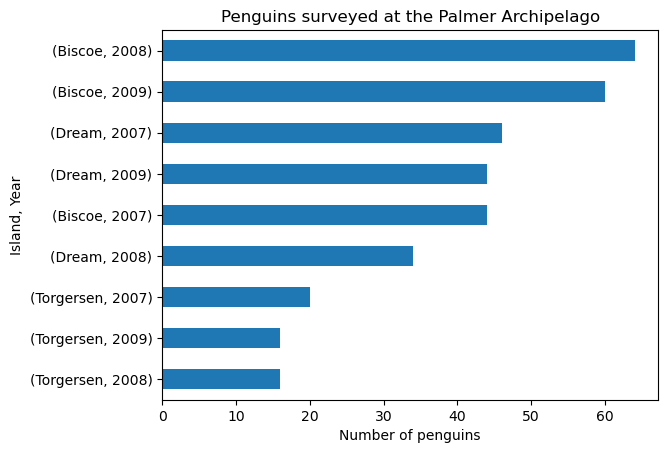

In [16]:
# Plotting surveyed population by island and year using method chaining:
(penguins.groupby(['island','year'])
         .size()
         .sort_values()
         .plot(kind='barh',
                title='Penguins surveyed at the Palmer Archipelago',
                xlabel='Number of penguins',
                ylabel='Island, Year')
         )

## Check-In:
1. Use the max() method to calculate the maximum value of a penguin’s body mass by year and species.
2. Use (1) to display the highest body masses per year and species as a bar plot in descending order.

In [17]:
# Maximum value of a penguins body mass by year and species:
penguins.groupby(['year', 'species'])['body_mass_g'].max().reset_index()

,year,species,body_mass_g
0,2007,Adelie,4675.0
1,2007,Chinstrap,4400.0
2,2007,Gentoo,6300.0
3,2008,Adelie,4700.0
4,2008,Chinstrap,4800.0
5,2008,Gentoo,6000.0
6,2009,Adelie,4775.0
7,2009,Chinstrap,4450.0
8,2009,Gentoo,6000.0


<Axes: title={'center': 'Penguins Mass (g) by Year and Species'}, xlabel='Body Mass (g)', ylabel='Year, Species'>

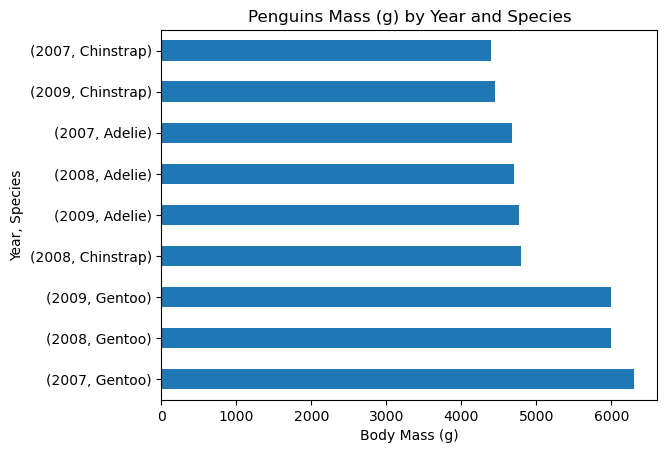

In [18]:
(penguins.groupby(['year', 'species'])['body_mass_g']
         .max()
         .sort_values(ascending = False)
         .plot(kind='barh',
                title='Penguins Mass (g) by Year and Species',
                xlabel='Body Mass (g)',
                ylabel='Year, Species')
         )